<!-- launch-badges -->
<a href="https://colab.research.google.com/github/laban254/ml-for-infrastructure/blob/main/03_machine_learning/scikit-learn/model-evaluation-and-selection/metrics.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
&nbsp;
<a href="https://mybinder.org/v2/gh/laban254/ml-for-infrastructure/main?urlpath=lab/tree/03_machine_learning/scikit-learn/model-evaluation-and-selection/metrics.ipynb" target="_blank"><img src="https://mybinder.org/badge_logo.svg" alt="Open in Binder"/></a>

> ▶️ **Run this notebook live** — no install needed. Click a badge above to open it in a free cloud runtime.

# Model Evaluation: Metrics for SRE

## Context
In observability and DevOps, the standard Machine Learning metric—**Accuracy**—is usually a terrible trap. 

Consider an alert system predicting Server Outages. If your servers are healthy 98% of the time, a "dumb" model that simply hardcodes `return "Healthy"` every single time will achieve **98% Accuracy**. But it will completely fail to detect the 2% of the time your database crashes, making it useless.

To build effective ML-driven alerting, we must understand the difference between **Precision**, **Recall**, **F1-Score**, and **Confusion Matrices**.

## Objectives
- Synthesize an imbalanced, realistically overlapping SRE dataset (Fraud/DDoS detection).
- Build a basic classification model and compare it against a naive "always predict the majority class" baseline.
- Understand the implications of False Positives (Alert Fatigue) vs False Negatives (Missed Outages).
- Calculate and interpret Precision, Recall, F1, and the ROC-AUC score.

## Expected Outcome
- A concrete, numeric demonstration of the accuracy trap: a naive baseline that hits ~98% accuracy while catching zero real attacks, next to a real model whose accuracy is only slightly higher but whose precision/recall/F1 tell a completely different (and truthful) story.
- A trained model with imperfect but strong precision/recall (not the unrealistic ~100% you'd get from perfectly separated classes), including a confusion matrix with real off-diagonal counts to interpret.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

### 1. Generating Imbalanced Observability Data
Let's simulate 10,000 API requests. Only ~2% of them are malicious (DDoS/Scraping).

In [2]:
np.random.seed(42)
n_samples = 10000

# 98% Normal traffic
normal_requests = pd.DataFrame({
    'Request_Rate': np.random.normal(50, 15, 9800),
    'Payload_Size': np.random.normal(1024, 300, 9800),
    'Status': 0
})

# 2% Malicious traffic -- means are much closer to normal traffic than a
# textbook example would use, and variance is wide, so the two classes
# genuinely overlap. A real detector has to work for its accuracy here.
malicious_requests = pd.DataFrame({
    'Request_Rate': np.random.normal(118, 34, 200),
    'Payload_Size': np.random.normal(1980, 510, 200),
    'Status': 1
})

df = pd.concat([normal_requests, malicious_requests])

X = df[['Request_Rate', 'Payload_Size']]
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print("Percentage of Malicious Requests: {:.2f}%".format(y.mean() * 100))

Percentage of Malicious Requests: 2.00%


### 2. Training the Detector

In [3]:
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### 2b. The Accuracy Trap, Concretely
Before looking at our model's metrics, let's build the "dumb" model from the intro for real: a baseline that always predicts the majority class (`Normal`). If accuracy alone told the whole story, this baseline should look great — let's see.

In [4]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

print("Naive Baseline (always predicts 'Normal'):")
print("  Accuracy:  {:.4f}".format(accuracy_score(y_test, baseline_pred)))
print("  Precision: {:.4f}".format(precision_score(y_test, baseline_pred, zero_division=0)))
print("  Recall:    {:.4f}".format(recall_score(y_test, baseline_pred, zero_division=0)))
print("  F1-Score:  {:.4f}".format(f1_score(y_test, baseline_pred, zero_division=0)))
print("\nReal Model (RandomForestClassifier):")
print("  Accuracy:  {:.4f}".format(accuracy_score(y_test, y_pred)))
print("  Precision: {:.4f}".format(precision_score(y_test, y_pred, zero_division=0)))
print("  Recall:    {:.4f}".format(recall_score(y_test, y_pred, zero_division=0)))
print("  F1-Score:  {:.4f}".format(f1_score(y_test, y_pred, zero_division=0)))

# Notice how close the two Accuracy scores are -- the naive baseline "looks"
# almost as good as the real model on that one metric alone, despite catching
# zero attacks. Precision/Recall/F1 are where the real model actually earns its keep.

Naive Baseline (always predicts 'Normal'):
  Accuracy:  0.9800
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

Real Model (RandomForestClassifier):
  Accuracy:  0.9963
  Precision: 0.9153
  Recall:    0.9000
  F1-Score:  0.9076


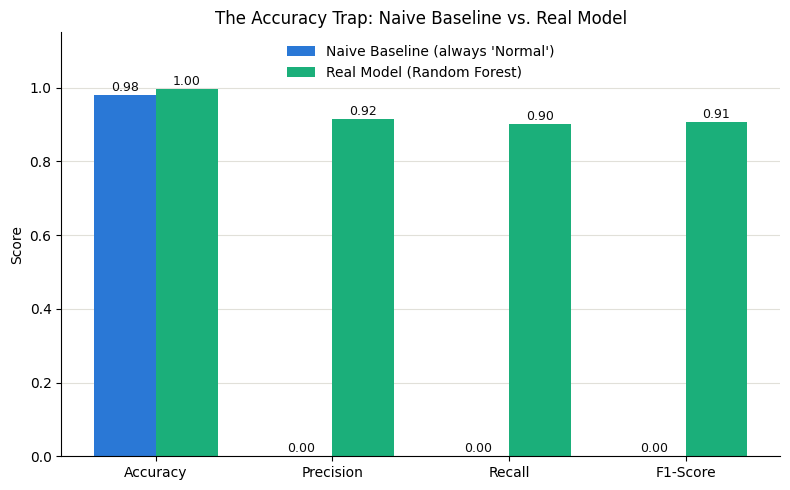

In [5]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_scores = [
    accuracy_score(y_test, baseline_pred),
    precision_score(y_test, baseline_pred, zero_division=0),
    recall_score(y_test, baseline_pred, zero_division=0),
    f1_score(y_test, baseline_pred, zero_division=0),
]
model_scores = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0),
    f1_score(y_test, y_pred, zero_division=0),
]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
baseline_bars = ax.bar(x - width/2, baseline_scores, width, label="Naive Baseline (always 'Normal')", color='#2a78d6')
model_bars = ax.bar(x + width/2, model_scores, width, label='Real Model (Random Forest)', color='#1baf7a')

for bars in (baseline_bars, model_bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9, color='#0b0b0b')

ax.set_ylabel('Score')
ax.set_title("The Accuracy Trap: Naive Baseline vs. Real Model")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.15)
ax.legend(frameon=False, loc='upper center')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 3. The Confusion Matrix
A confusion matrix tells us exactly the types of mistakes our model made.

- **True Negatives (TN):** Model says Normal, Traffic is Normal. (Good)
- **True Positives (TP):** Model says Attack, Traffic is Attack. (Good)
- **False Positives (FP) [Type I Error]:** Model says Attack, Traffic is Normal. (**Paging engineer at 3 AM for nothing! Alert Fatigue!**)
- **False Negatives (FN) [Type II Error]:** Model says Normal, Traffic is Attack. (**System goes down unmonitored!**)

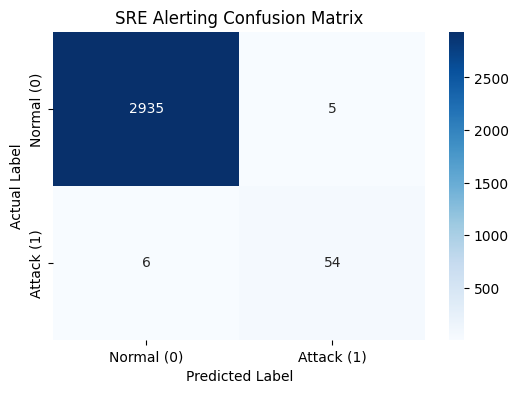

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Normal (0)', 'Attack (1)'], yticklabels=['Normal (0)', 'Attack (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('SRE Alerting Confusion Matrix')
plt.show()

### 4. Advanced Metrics

#### Precision: Out of all the alerts you fired, how many were real?
Formula: `TP / (TP + FP)`
*Why it matters in SRE:* Low precision means high False Positives. This causes **Alert Fatigue**, where engineers start ignoring PagerDuty.

#### Recall (Sensitivity): Out of all the real attacks, how many did you catch?
Formula: `TP / (TP + FN)`
*Why it matters in SRE:* Low recall means high False Negatives. This causes **Missed Incidents** and downtime.

#### F1-Score: The harmonic mean of Precision and Recall
Used when you need a balance between the two.

In [7]:
print("Accuracy:  {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Precision: {:.4f} (When I page you, I am correct {}% of the time)".format(precision_score(y_test, y_pred), round(precision_score(y_test, y_pred)*100)))
print("Recall:    {:.4f} (Out of all attacks, I caught {}% of them)".format(recall_score(y_test, y_pred), round(recall_score(y_test, y_pred)*100)))
print("F1-Score:  {:.4f}".format(f1_score(y_test, y_pred)))

# Notice that while Accuracy is extremely high, Precision/Recall paint the real picture of the alerting system.

Accuracy:  0.9963
Precision: 0.9153 (When I page you, I am correct 92% of the time)
Recall:    0.9000 (Out of all attacks, I caught 90% of them)
F1-Score:  0.9076


### 5. ROC-AUC Score
The Receiver Operating Characteristic - Area Under Curve (ROC-AUC) measures the model's ability to distinguish between classes unconditionally across all possible threshold values. 
- `1.0` is perfect.
- `0.5` is random guessing.

In [8]:
# ROC-AUC requires predicted probabilities, not just hard labels [0,1]
y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9994


### Summary
As an SRE/Data Scientist, you must tune your model's threshold depending on the business context:
- If missing an attack is catastrophic (e.g., banking), you optimize for **Recall** (even if it means PagerDuty goes off more often).
- If alerts are just warnings for a non-critical background job, you optimize for **Precision** to protect your engineers' sleep.